<a href="https://colab.research.google.com/github/sharonedassery/An-intelligent-analysis-using-unsupervised-leaning-for-a-weather-dataset-a-/blob/main/NZ_Age_Area_LookSharp_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
file_path = "/content/nz_age_area.csv"   # change if your filename is different

df = pd.read_csv(file_path)
print(df.columns.tolist())
df.head()

['Year as at 30 June', 'Measure', 'Sex', 'Age group', 'Territorial authority', 'Territorial authority Code', 'Value', 'Value Unit', 'Value Label', 'Null Reason']


,Year as at 30 June,Measure,Sex,Age group,Territorial authority,Territorial authority Code,Value,Value Unit,Value Label,Null Reason
0,1996,Estimated population,Male,0-4,Far North,Far North District,2520.0,number,Number of people,NaN
1,1996,Estimated population,Male,0-4,Whangārei,Whangarei District,2960.0,number,Number of people,NaN
2,1996,Estimated population,Male,0-4,Kaipara,Kaipara District,750.0,number,Number of people,NaN
3,1996,Estimated population,Male,0-4,Thames-Coromandel,Thames-Coromandel District,890.0,number,Number of people,NaN
4,1996,Estimated population,Male,0-4,Hauraki,Hauraki District,860.0,number,Number of people,NaN


In [4]:
df = df.rename(columns={
    "Territorial authority": "Area",
    "Age group": "Age group",
    "Value": "Population"
})


In [5]:
df[["Area", "Age group", "Population"]].head()

,Area,Age group,Population
0,Far North,0-4,2520.0
1,Whangārei,0-4,2960.0
2,Kaipara,0-4,750.0
3,Thames-Coromandel,0-4,890.0
4,Hauraki,0-4,860.0


In [6]:
# Keep only needed columns
df = df[["Area", "Age group", "Population"]].copy()

# Convert population to numeric
df["Population"] = pd.to_numeric(df["Population"], errors="coerce")

# Remove empty rows
df = df.dropna(subset=["Population"])

# Remove unwanted age labels if any
remove_values = ["Total", "All ages", "Unknown", "Not stated"]
df = df[~df["Age group"].isin(remove_values)]

print(df.shape)
df.head()

(150075, 3)


,Area,Age group,Population
0,Far North,0-4,2520.0
1,Whangārei,0-4,2960.0
2,Kaipara,0-4,750.0
3,Thames-Coromandel,0-4,890.0
4,Hauraki,0-4,860.0


In [7]:
# Total population per area
area_total = df.groupby("Area")["Population"].sum().reset_index()
area_total = area_total.rename(columns={"Population": "Area Total"})

# Merge back
df = df.merge(area_total, on="Area", how="left")

# Calculate percentage
df["Age Percentage"] = (df["Population"] / df["Area Total"]) * 100

df.head()

,Area,Age group,Population,Area Total,Age Percentage
0,Far North,0-4,2520.0,10750680.0,0.023440
1,Whangārei,0-4,2960.0,14336344.8,0.020647
2,Kaipara,0-4,750.0,3617577.0,0.020732
3,Thames-Coromandel,0-4,890.0,4892396.3,0.018191
4,Hauraki,0-4,860.0,3350754.7,0.025666


In [8]:
dominant_age = df.loc[df.groupby("Area")["Age Percentage"].idxmax()]

dominant_age = dominant_age[["Area", "Age group", "Age Percentage"]]
dominant_age = dominant_age.sort_values("Area")

dominant_age.head(20)

,Area,Age group,Age Percentage
148141,Area Outside Territorial Authority,total,1.022883
150059,Ashburton,total,0.692124
150072,Auckland,total,0.713036
148120,Buller,total,0.601608
150046,Carterton,total,0.718152
150029,Central Hawke's Bay,total,0.664270
150065,Central Otago,total,0.780429
148131,Chatham Islands,total,0.634324
150057,Christchurch,total,0.649919
150068,Clutha,total,0.604383


In [9]:
def suggest_products(age_group):
    age_group = str(age_group).lower()

    if "0" in age_group or "5" in age_group or "10" in age_group:
        return "Kids party items, balloons, return gifts, cartoon themes"

    elif "15" in age_group or "20" in age_group:
        return "Glow party items, novelty accessories, themed decorations"

    elif "25" in age_group or "30" in age_group:
        return "Birthday décor, tableware, celebration packs, baby shower items"

    elif "35" in age_group or "40" in age_group:
        return "Family party supplies, school event items, home decorations"

    elif "50" in age_group or "60" in age_group:
        return "Milestone birthday décor, simple celebration items"

    elif "65" in age_group or "70" in age_group:
        return "Simple décor, family gathering supplies"

    else:
        return "General party supplies"

dominant_age["Suggested LookSharp Products"] = dominant_age["Age group"].apply(suggest_products)

dominant_age.head(20)

,Area,Age group,Age Percentage,Suggested LookSharp Products
148141,Area Outside Territorial Authority,total,1.022883,General party supplies
150059,Ashburton,total,0.692124,General party supplies
150072,Auckland,total,0.713036,General party supplies
148120,Buller,total,0.601608,General party supplies
150046,Carterton,total,0.718152,General party supplies
150029,Central Hawke's Bay,total,0.664270,General party supplies
150065,Central Otago,total,0.780429,General party supplies
148131,Chatham Islands,total,0.634324,General party supplies
150057,Christchurch,total,0.649919,General party supplies
150068,Clutha,total,0.604383,General party supplies


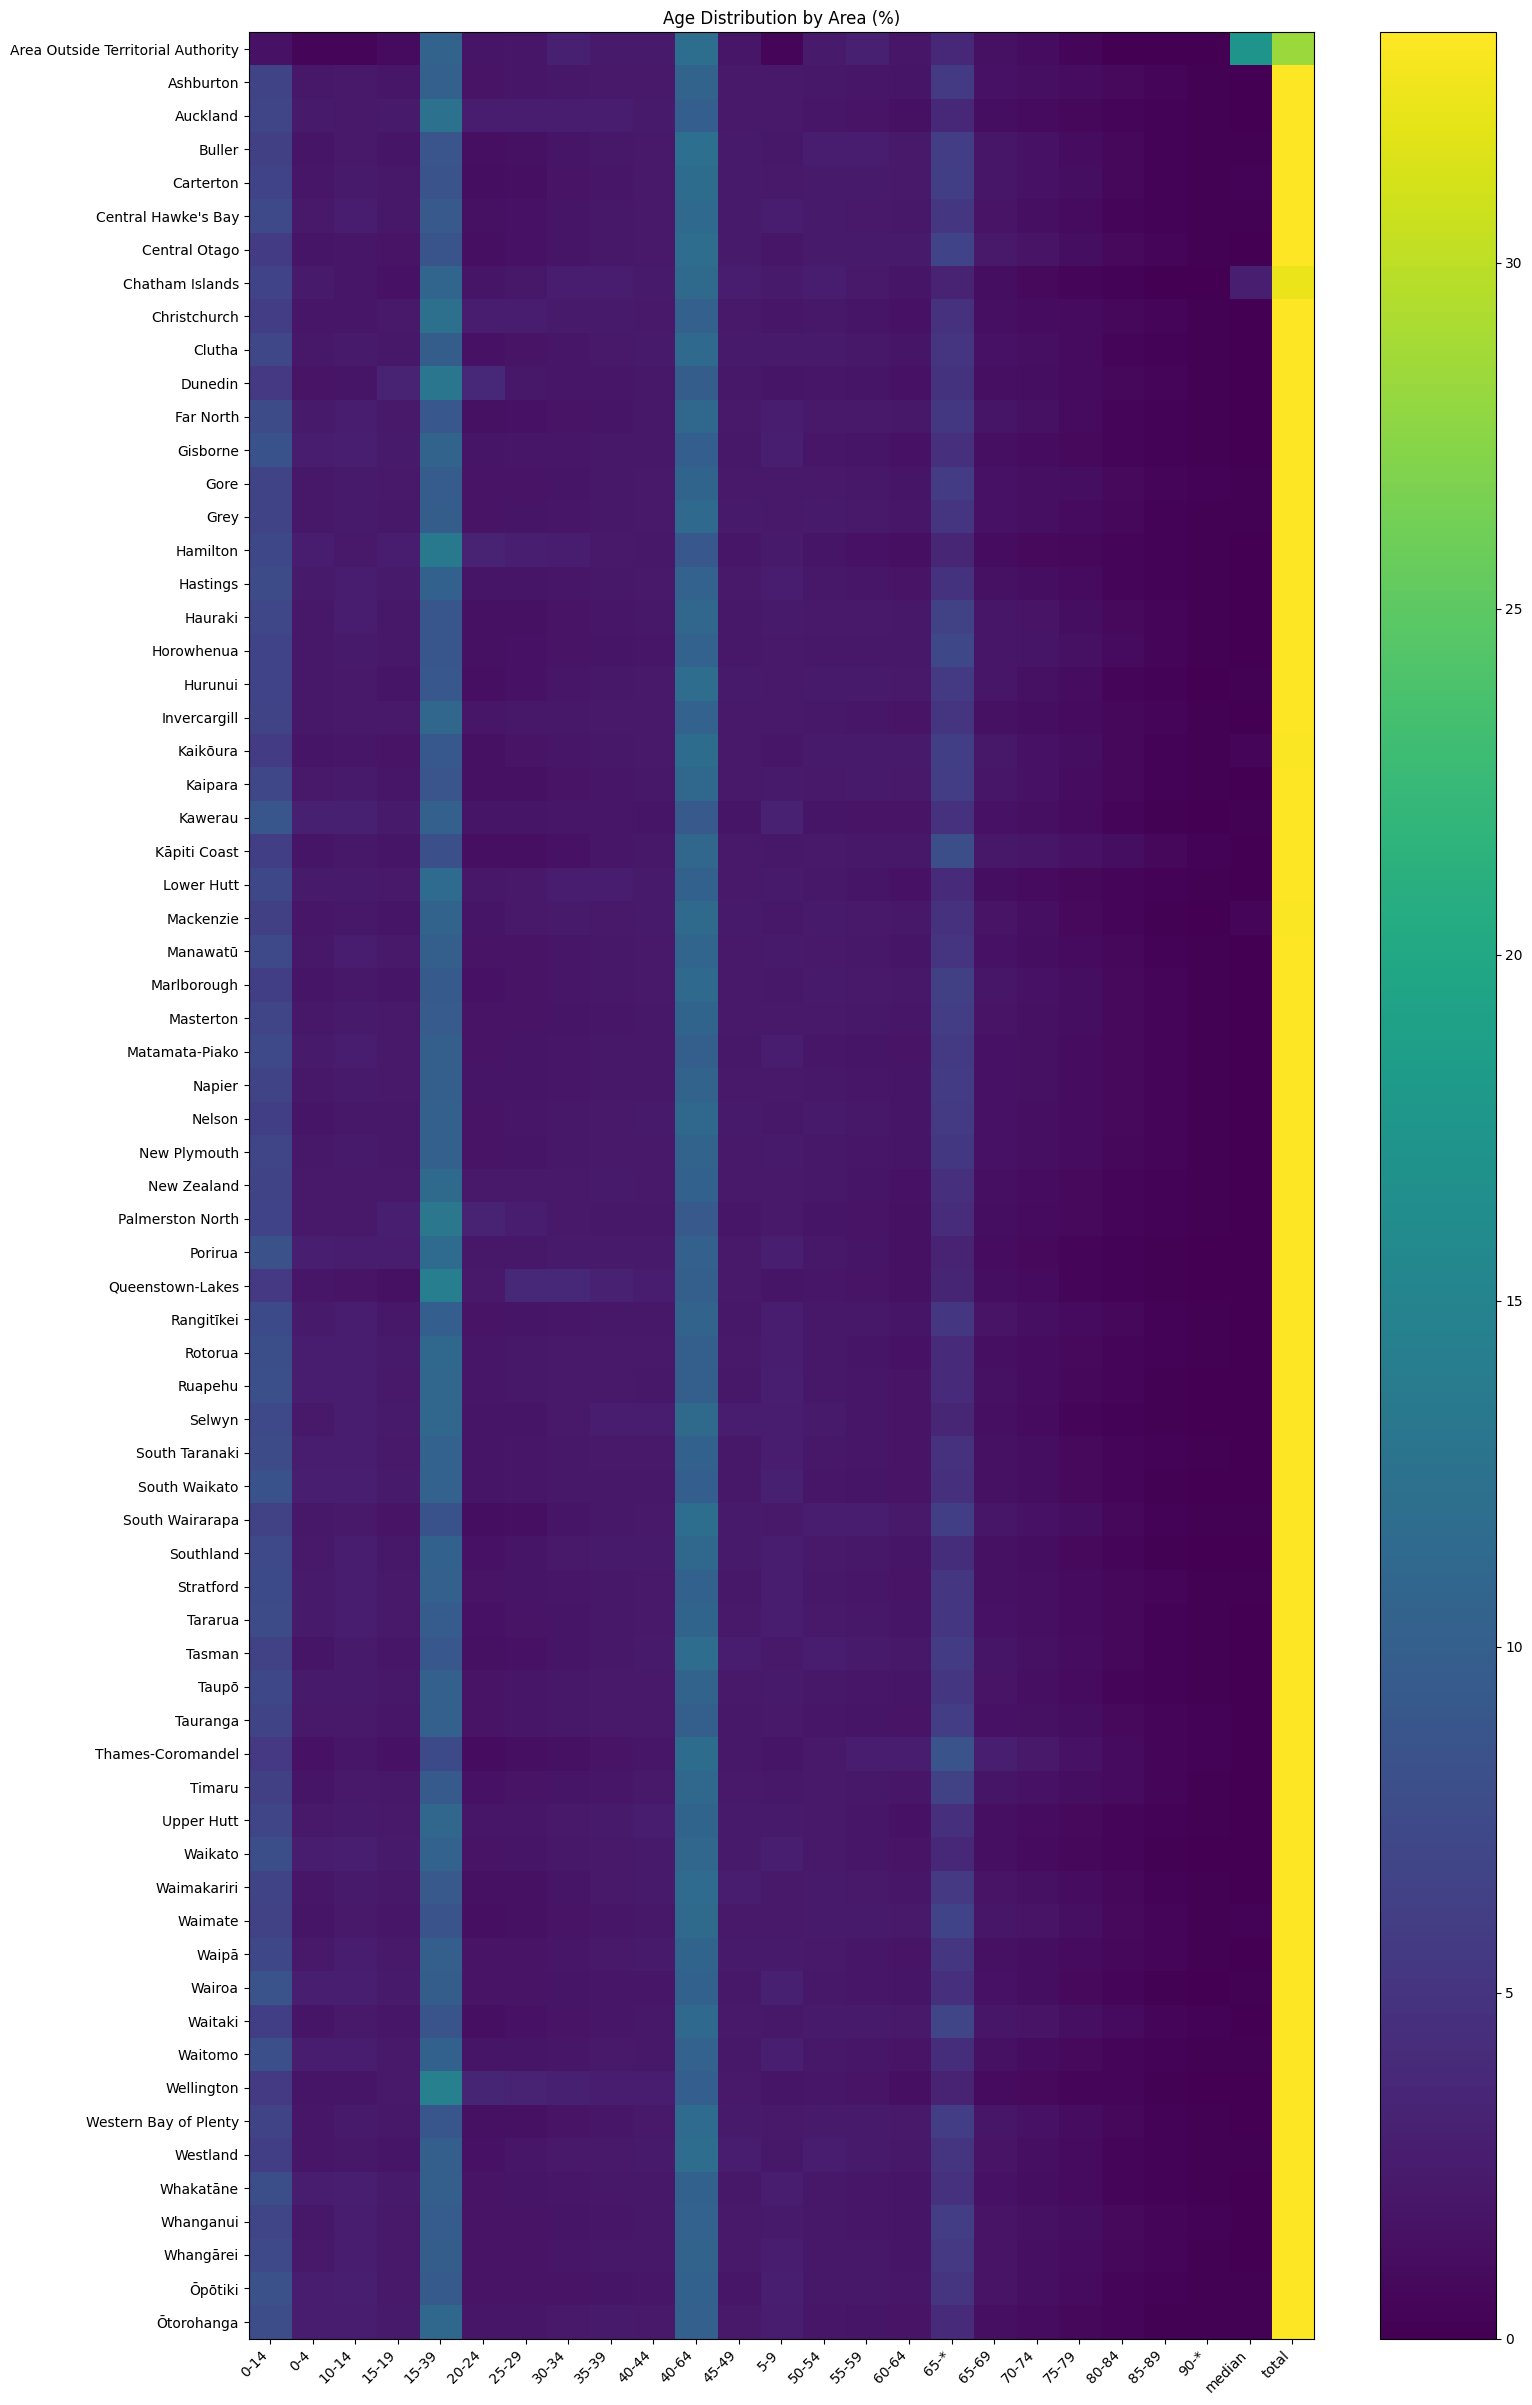

In [10]:
pivot_table = df.pivot_table(
    index="Area",
    columns="Age group",
    values="Age Percentage",
    aggfunc="sum",
    fill_value=0
)

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(16, max(8, len(pivot_table) * 0.35)))

im = ax.imshow(pivot_table.values, aspect="auto")

ax.set_xticks(np.arange(len(pivot_table.columns)))
ax.set_xticklabels(pivot_table.columns, rotation=45, ha="right")

ax.set_yticks(np.arange(len(pivot_table.index)))
ax.set_yticklabels(pivot_table.index)

ax.set_title("Age Distribution by Area (%)")

plt.colorbar(im)
plt.tight_layout()
plt.show()

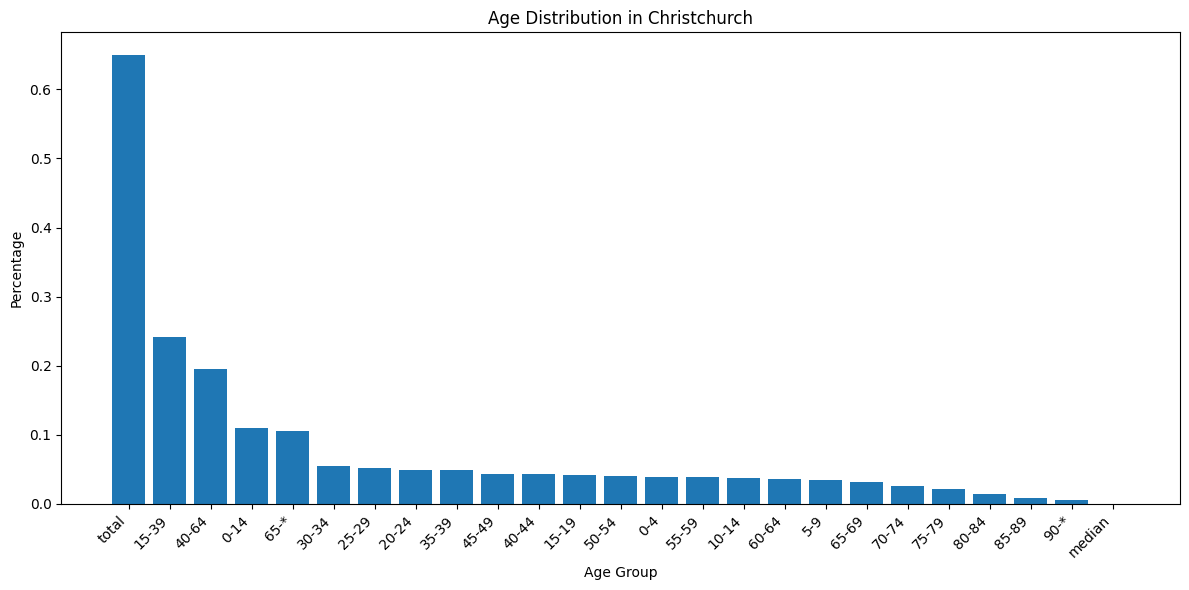

In [13]:
selected_area = "Christchurch"

area_df = df[df["Area"] == selected_area].sort_values("Age Percentage", ascending=False)

plt.figure(figsize=(12,6))
plt.bar(area_df["Age group"], area_df["Age Percentage"])
plt.xticks(rotation=45, ha="right")

plt.title(f"Age Distribution in {selected_area}")
plt.ylabel("Percentage")
plt.xlabel("Age Group")

plt.tight_layout()
plt.show()

In [12]:
print(sorted(df["Area"].unique()))

['Area Outside Territorial Authority', 'Ashburton', 'Auckland', 'Buller', 'Carterton', "Central Hawke's Bay", 'Central Otago', 'Chatham Islands', 'Christchurch', 'Clutha', 'Dunedin', 'Far North', 'Gisborne', 'Gore', 'Grey', 'Hamilton', 'Hastings', 'Hauraki', 'Horowhenua', 'Hurunui', 'Invercargill', 'Kaikōura', 'Kaipara', 'Kawerau', 'Kāpiti Coast', 'Lower Hutt', 'Mackenzie', 'Manawatū', 'Marlborough', 'Masterton', 'Matamata-Piako', 'Napier', 'Nelson', 'New Plymouth', 'New Zealand', 'Palmerston North', 'Porirua', 'Queenstown-Lakes', 'Rangitīkei', 'Rotorua', 'Ruapehu', 'Selwyn', 'South Taranaki', 'South Waikato', 'South Wairarapa', 'Southland', 'Stratford', 'Tararua', 'Tasman', 'Taupō', 'Tauranga', 'Thames-Coromandel', 'Timaru', 'Upper Hutt', 'Waikato', 'Waimakariri', 'Waimate', 'Waipā', 'Wairoa', 'Waitaki', 'Waitomo', 'Wellington', 'Western Bay of Plenty', 'Westland', 'Whakatāne', 'Whanganui', 'Whangārei', 'Ōpōtiki', 'Ōtorohanga']


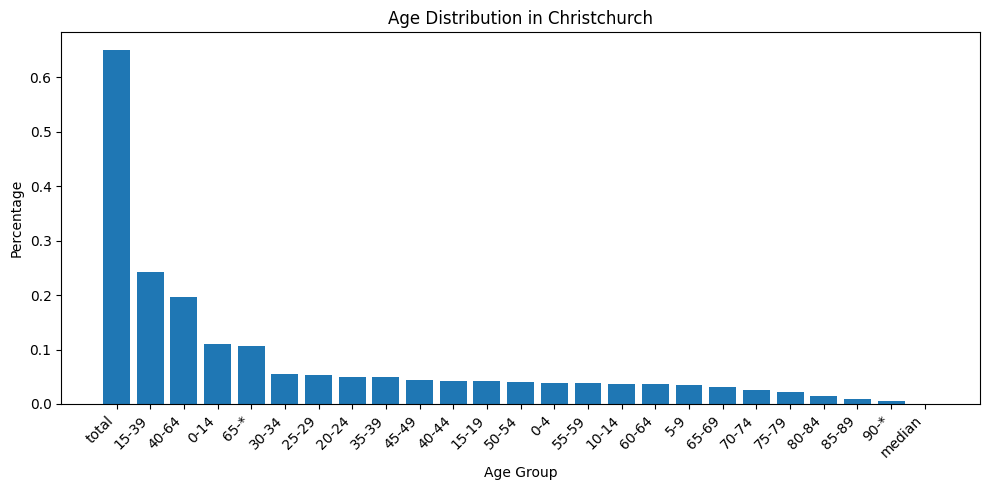

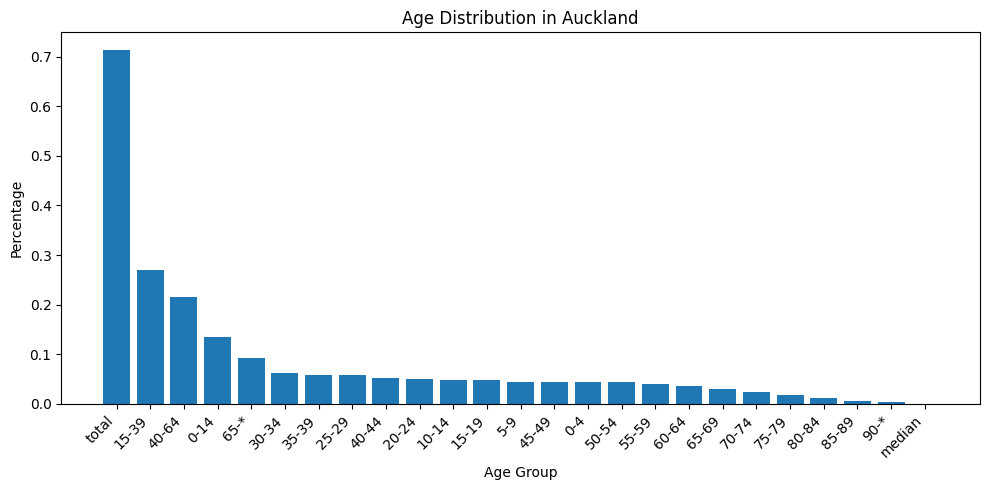

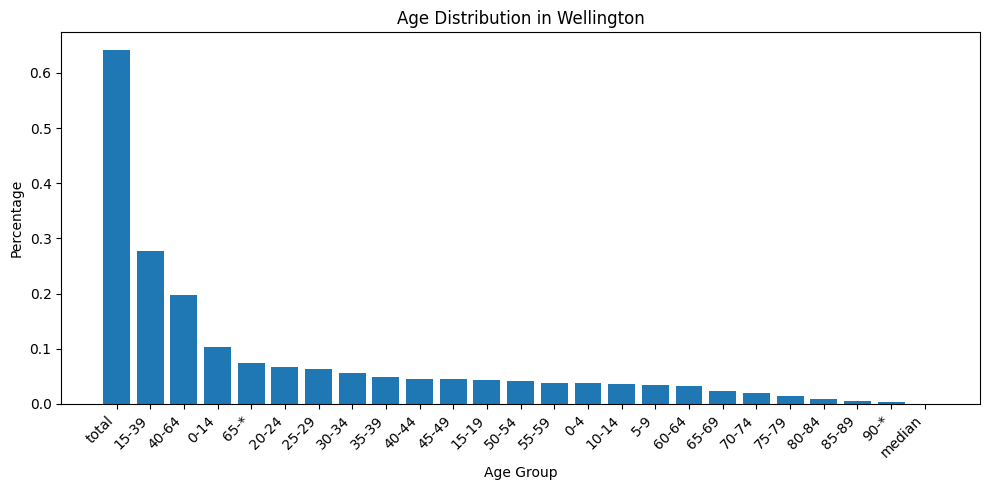

In [14]:
areas = ["Christchurch", "Auckland", "Wellington"]

for area in areas:
    area_df = df[df["Area"] == area].sort_values("Age Percentage", ascending=False)

    plt.figure(figsize=(10,5))
    plt.bar(area_df["Age group"], area_df["Age Percentage"])
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Age Distribution in {area}")
    plt.ylabel("Percentage")
    plt.xlabel("Age Group")
    plt.tight_layout()
    plt.show()